In [ ]:
import pandas as pd

df = pd.read_csv('/content/mobile phone price prediction (1).csv')

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (1370, 18)

Columns:
Index(['Unnamed: 0', 'Name', 'Rating', 'Spec_score', 'No_of_sim', 'Ram',
       'Battery', 'Display', 'Camera', 'External_Memory', 'Android_version',
       'Price', 'company', 'Inbuilt_memory', 'fast_charging',
       'Screen_resolution', 'Processor', 'Processor_name'],
      dtype='object')

Missing values:
Unnamed: 0             0
Name                   0
Rating                 0
Spec_score             0
No_of_sim              0
Ram                    0
Battery                0
Display                0
Camera                 0
External_Memory        0
Android_version      443
Price                  0
company                0
Inbuilt_memory        19
fast_charging         89
Screen_resolution      2
Processor             28
Processor_name         0
dtype: int64


In [ ]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Convert Price to numeric
df['Price'] = (
    df['Price']
        .astype(str)
            .str.replace(',', '', regex=False)
                .str.extract(r'(\d+\.?\d*)')[0]
                    .astype(float)
                    )

# Extract numerical values from important columns
df['RAM_GB'] = (
    df['Ram'].astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
            )

df['Battery_mAh'] = (
    df['Battery'].astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
            )

df['Display_inches'] = (
    df['Display'].astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
            )

df['Storage_GB'] = (
    df['Inbuilt_memory'].astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
            )

df['Android_version_num'] = (
    df['Android_version'].astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
            .astype(float)
            )

# Show processed data
df[['Price', 'Rating', 'Spec_score', 'RAM_GB',
    'Battery_mAh', 'Display_inches',
        'Storage_GB', 'Android_version_num']].head()

,Price,Rating,Spec_score,RAM_GB,Battery_mAh,Display_inches,Storage_GB,Android_version_num
0,9999.0,4.65,68,4.0,6000.0,6.6,128.0,13.0
1,9990.0,4.20,63,2.0,4000.0,6.4,32.0,10.0
2,11999.0,4.30,75,4.0,5000.0,6.6,64.0,12.0
3,11999.0,4.10,73,4.0,6000.0,6.4,64.0,12.0
4,11999.0,4.10,69,4.0,5000.0,6.5,64.0,11.0


In [ ]:
features = [
    'Rating',
    'Spec_score',
    'RAM_GB',
    'Battery_mAh',
    'Display_inches',
    'Storage_GB',
    'Android_version_num'
]

X = df[features]
y = df['Price']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Rating  Spec_score  RAM_GB  Battery_mAh  Display_inches  Storage_GB  \
0    4.65          68     4.0       6000.0             6.6       128.0   
1    4.20          63     2.0       4000.0             6.4        32.0   
2    4.30          75     4.0       5000.0             6.6        64.0   
3    4.10          73     4.0       6000.0             6.4        64.0   
4    4.10          69     4.0       5000.0             6.5        64.0   

   Android_version_num  
0                 13.0  
1                 10.0  
2                 12.0  
3                 12.0  
4                 11.0  

Target:
0     9999.0
1     9990.0
2    11999.0
3    11999.0
4    11999.0
Name: Price, dtype: float64


In [ ]:
X = X.fillna(X.median())
y = y.fillna(y.median())

print("Missing values after preprocessing:")
print(X.isnull().sum())

Missing values after preprocessing:
Rating                 0
Spec_score             0
RAM_GB                 0
Battery_mAh            0
Display_inches         0
Storage_GB             0
Android_version_num    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1096, 7)
Testing data: (274, 7)


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual Prices:")
print(y_test.head(10).values)

print("\nPredicted Prices:")
print(y_pred[:10])

Actual Prices:
[28999. 30999. 72999. 27990. 11990. 39990. 56990.  8199. 59999. 10999.]

Predicted Prices:
[44614.68093053 35521.37200639 43959.73409404 49314.76233515
  4882.98972974 47543.93177427 49876.96714153 11932.18168721
 45538.40002335 18794.93546787]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 14155.82
Mean Squared Error (MSE): 465602738.77
Root Mean Squared Error (RMSE): 21577.83
R-squared (R2): 0.48


In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Performance
------------------
MAE  : 14155.82
RMSE : 21577.83
R² Score: 0.4835


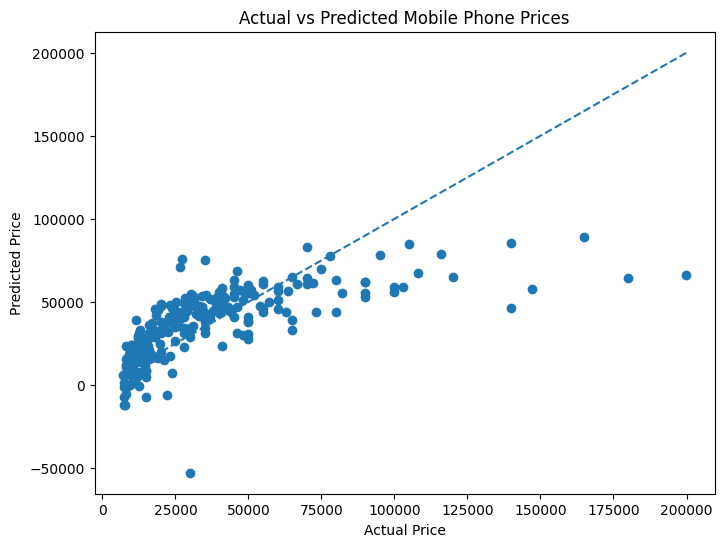

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Mobile Phone Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

               Feature  Coefficient
1           Spec_score  1775.353002
5           Storage_GB    83.770977
2               RAM_GB    -2.208889
3          Battery_mAh   -10.151900
4       Display_inches   -13.289051
6  Android_version_num -1750.674480
0               Rating -1931.550073


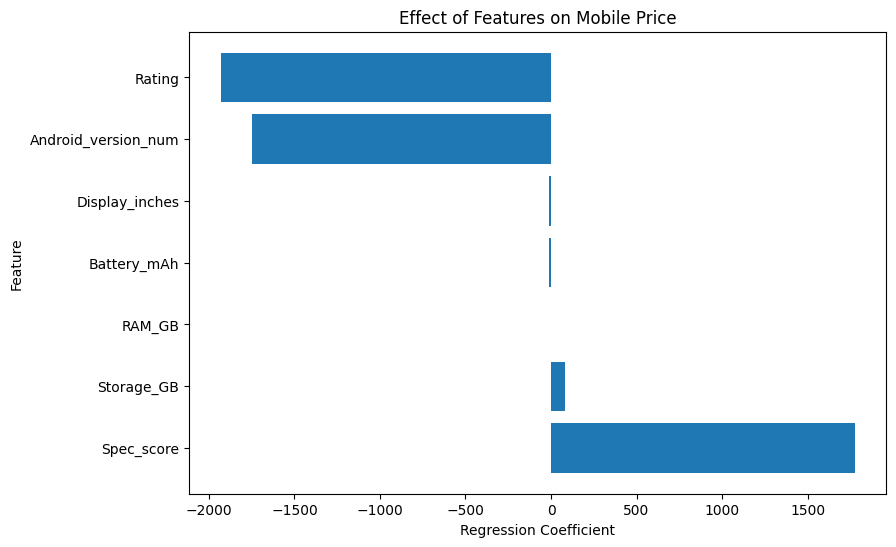

In [ ]:
plt.figure(figsize=(9,6))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Effect of Features on Mobile Price")

plt.show()

In [ ]:
new_mobile = pd.DataFrame({
    'Rating': [4.3],
    'Spec_score': [75],
    'RAM_GB': [8],
    'Battery_mAh': [5000],
    'Display_inches': [6.6],
    'Storage_GB': [128],
    'Android_version_num': [13]
})

predicted_price = model.predict(new_mobile)

print("Predicted Mobile Price: ₹", round(predicted_price[0], 2))

Predicted Mobile Price: ₹ 19254.79
